Dieser Codeblock vergleicht **mehrere Klassifikationsmodelle** auf einem Datensatz mithilfe einer **robusten repeated stratified cross-validation**:

- lädt eine Excel-Datei mit einer **binären Zielvariable**,
- behält nur **numerische Features**,
- erstellt für jedes Modell eine Pipeline aus **Median-Imputation**, **Standardisierung** und **Klassifikator**,
- testet verschiedene Modelle wie **Logistic Regression, Random Forest, XGBoost, LightGBM, SVC, kNN, MLP, Naive Bayes, LDA, QDA, Bagging und Extra Trees**,
- führt für jedes Modell eine **5×10 Repeated Stratified Cross-Validation** durch,
- berechnet Metriken wie **Train/Test Accuracy, Balanced Accuracy, F1, Recall, Precision, ROC-AUC, PR-AUC, Brier Score und LogLoss**,
- mittelt diese Metriken über alle Folds,
- sortiert die Modelle nach **ROC-AUC**,
- und zeigt die Ergebnisse als **scrollbare Vergleichstabelle** an.

Ziel ist ein **systematischer interner Modellvergleich**, um zu sehen, welche Algorithmen auf dem Datensatz am besten performen.

In [1]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\Basistabelle_alle_PostOP_ML.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression
Validiere Modell: Decision Tree
Validiere Modell: Random Forest
Validiere Modell: Gradient Boosting
Validiere Modell: XGBoost
Validiere Modell: LightGBM
Validiere Modell: SVC
Validiere Modell: k-Nearest Neighbors
Validiere Modell: MLP Classifier
Validiere Modell: Gaussian Naive Bayes
Validiere Modell: Linear Discriminant Analysis
Validiere Modell: Quadratic Discriminant Analysis
Validiere Modell: Bagging Classifier
Validiere Modell: Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
Logistic Regression,1.000 ± 0.000,0.883 ± 0.060,0.883 ± 0.059,0.887 ± 0.062,0.872 ± 0.101,0.915 ± 0.078,0.958 ± 0.043,0.955 ± 0.063,0.081 ± 0.034,0.326 ± 0.245
MLP Classifier,1.000 ± 0.000,0.864 ± 0.058,0.864 ± 0.058,0.870 ± 0.061,0.856 ± 0.105,0.897 ± 0.081,0.945 ± 0.044,0.960 ± 0.036,0.103 ± 0.040,0.348 ± 0.148
SVC,0.977 ± 0.010,0.840 ± 0.069,0.839 ± 0.070,0.852 ± 0.064,0.856 ± 0.094,0.858 ± 0.087,0.934 ± 0.044,0.952 ± 0.033,0.112 ± 0.036,0.354 ± 0.099
XGBoost,1.000 ± 0.000,0.829 ± 0.068,0.832 ± 0.069,0.833 ± 0.071,0.800 ± 0.104,0.883 ± 0.089,0.931 ± 0.043,0.948 ± 0.039,0.119 ± 0.045,0.383 ± 0.143
Extra Trees,1.000 ± 0.000,0.830 ± 0.074,0.830 ± 0.076,0.840 ± 0.071,0.835 ± 0.102,0.859 ± 0.100,0.925 ± 0.051,0.945 ± 0.040,0.127 ± 0.025,0.409 ± 0.059
Gradient Boosting,1.000 ± 0.000,0.838 ± 0.085,0.840 ± 0.086,0.845 ± 0.081,0.819 ± 0.096,0.881 ± 0.104,0.921 ± 0.059,0.942 ± 0.048,0.136 ± 0.071,0.610 ± 0.392
LightGBM,1.000 ± 0.000,0.814 ± 0.068,0.816 ± 0.069,0.818 ± 0.075,0.790 ± 0.112,0.865 ± 0.091,0.915 ± 0.044,0.935 ± 0.038,0.133 ± 0.045,0.424 ± 0.148
Random Forest,1.000 ± 0.000,0.813 ± 0.067,0.813 ± 0.070,0.826 ± 0.061,0.820 ± 0.084,0.842 ± 0.091,0.914 ± 0.044,0.939 ± 0.032,0.138 ± 0.023,0.441 ± 0.053
Bagging Classifier,0.983 ± 0.015,0.804 ± 0.069,0.810 ± 0.068,0.799 ± 0.079,0.739 ± 0.122,0.891 ± 0.092,0.897 ± 0.059,0.911 ± 0.056,0.133 ± 0.037,0.530 ± 0.327
Gaussian Naive Bayes,0.906 ± 0.021,0.840 ± 0.062,0.837 ± 0.065,0.858 ± 0.052,0.882 ± 0.069,0.841 ± 0.083,0.897 ± 0.066,0.881 ± 0.081,0.148 ± 0.061,1.589 ± 0.857


Dieser Codeblock identifiziert **Gruppen stark korrelierter numerischer Features** in einem Datensatz und visualisiert deren Zusammenhang:

- lädt eine Excel-Datei,
- entfernt die Zielvariable,
- berechnet die **absolute Korrelationsmatrix** aller numerischen Features,
- bildet **Cluster von Features**, die direkt oder indirekt mit **|r| > 0.9** verbunden sind,
- behält nur Cluster mit **mindestens 2 Features**,
- gibt diese Cluster in der Konsole aus,
- erstellt eine **Heatmap der Korrelationsmatrix**, geordnet nach den gefundenen Clustern,
- und zeigt zusätzlich die geordnete Korrelationsmatrix als **scrollbare HTML-Tabelle** an.

Ziel ist es, **stark redundante oder zusammenhängende Feature-Gruppen** im Datensatz sichtbar zu machen.

Gefundene Cluster mit ≥2 Features:
Cluster 2 (6 Features):
  ['CMJ_Jump Height flighttime', 'CMJ_Net Impulse', 'CMJ_Net landing impulse', 'CMJ_Rel. Peak Power', 'INV_CMJ_uni_Rel. Peak Power ', 'UNINV_CMJ_uni_Rel. Peak Power ']

Cluster 3 (5 Features):
  ['CMJ_Vertical Takeoff velocity', 'INV_CMJ_uni_Vertical Take-Off Velocity by Net Impulse-Mittelwert [m/s]', 'UNINV_CMJ_uni_Vertical Take-Off Velocity by Net Impulse-Mittelwert [m/s]', 'INV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s]', 'UNINV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s]']

Cluster 15 (6 Features):
  ['CMJ_Peak braking force', 'INV_CMJ_uni_Peak braking force ', 'UNINV_CMJ_uni_Peak braking force ', 'CMJ_Av. braking force', 'INV_CMJ_uni_Av. braking force ', 'UNINV_CMJ_uni_Av. braking force ']

Cluster 21 (3 Features):
  ['CMJ_Rel. Peak landing force', 'INV_CMJ_uni_Rel. Peak landing force ', 'UNINV_CMJ_uni_Rel. Peak landing force ']

Cluster 26 (6 Features):
  ['INV_CMJ_uni_Jump Height 

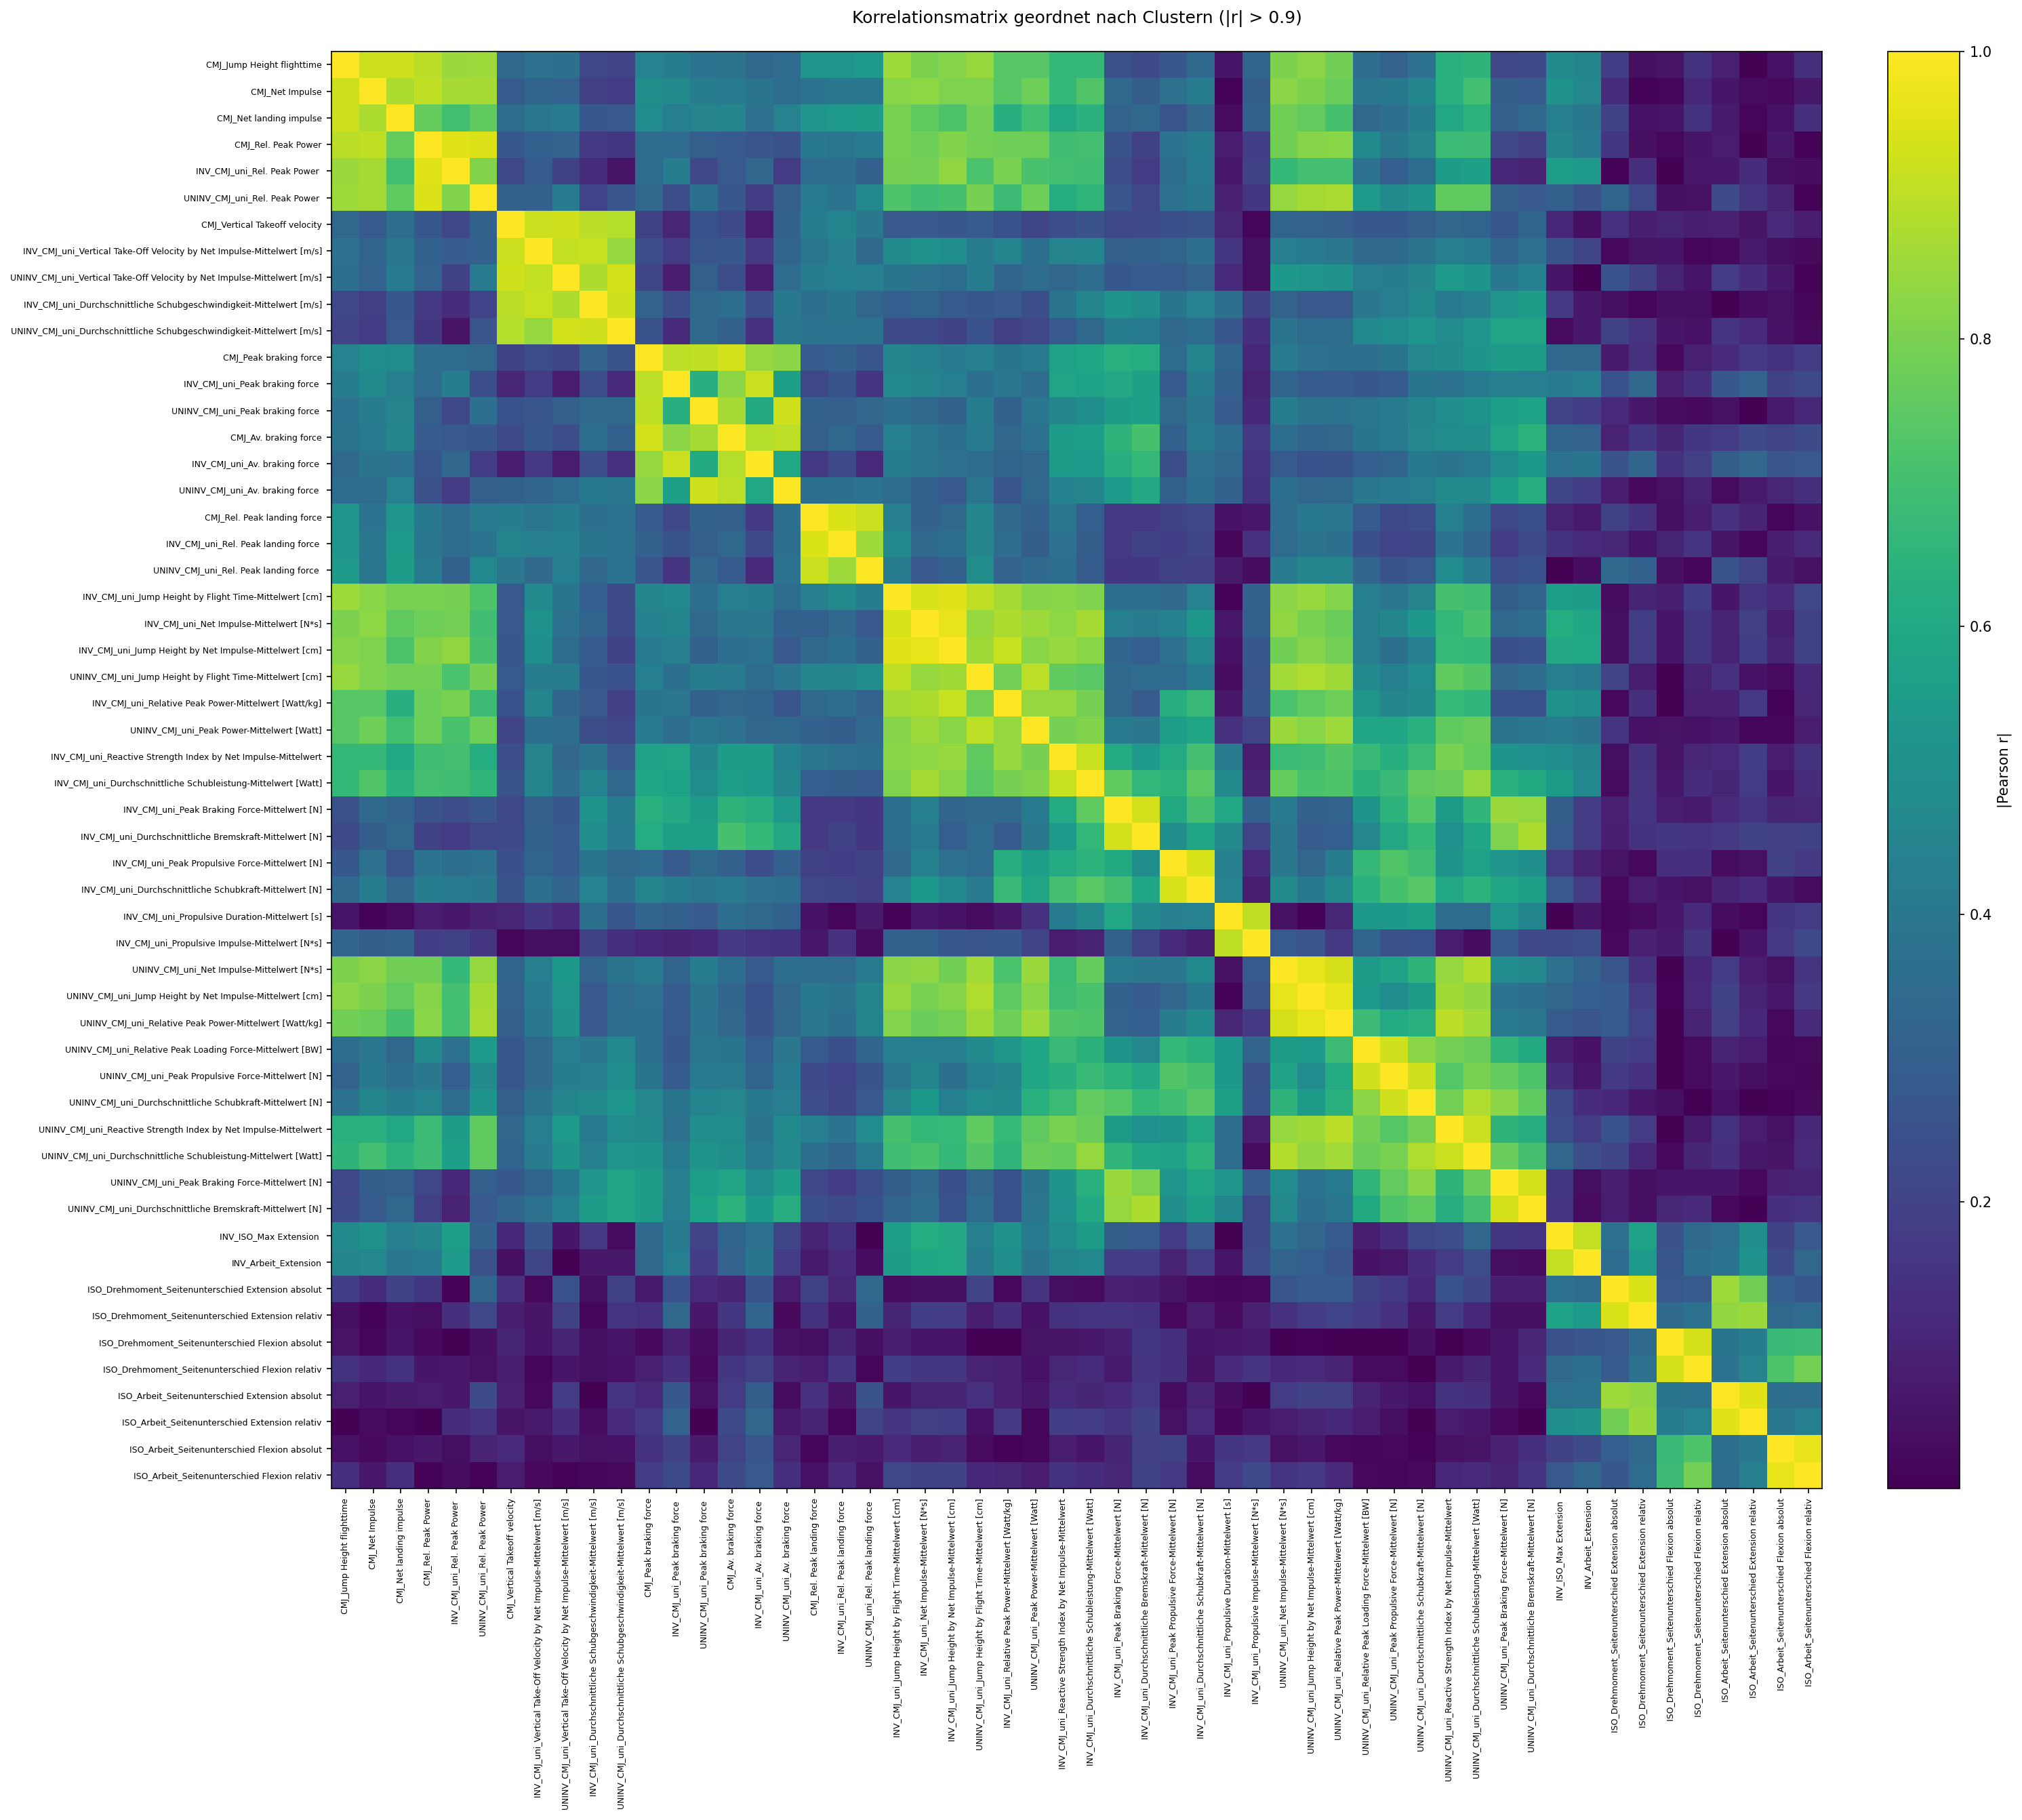

,CMJ_Jump Height flighttime,CMJ_Net Impulse,CMJ_Net landing impulse,CMJ_Rel. Peak Power,INV_CMJ_uni_Rel. Peak Power,UNINV_CMJ_uni_Rel. Peak Power,CMJ_Vertical Takeoff velocity,INV_CMJ_uni_Vertical Take-Off Velocity by Net Impulse-Mittelwert [m/s],UNINV_CMJ_uni_Vertical Take-Off Velocity by Net Impulse-Mittelwert [m/s],INV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s],UNINV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s],CMJ_Peak braking force,INV_CMJ_uni_Peak braking force,UNINV_CMJ_uni_Peak braking force,CMJ_Av. braking force,INV_CMJ_uni_Av. braking force,UNINV_CMJ_uni_Av. braking force,CMJ_Rel. Peak landing force,INV_CMJ_uni_Rel. Peak landing force,UNINV_CMJ_uni_Rel. Peak landing force,INV_CMJ_uni_Jump Height by Flight Time-Mittelwert [cm],INV_CMJ_uni_Net Impulse-Mittelwert [N*s],INV_CMJ_uni_Jump Height by Net Impulse-Mittelwert [cm],UNINV_CMJ_uni_Jump Height by Flight Time-Mittelwert [cm],INV_CMJ_uni_Relative Peak Power-Mittelwert [Watt/kg],UNINV_CMJ_uni_Peak Power-Mittelwert [Watt],INV_CMJ_uni_Reactive Strength Index by Net Impulse-Mittelwert,INV_CMJ_uni_Durchschnittliche Schubleistung-Mittelwert [Watt],INV_CMJ_uni_Peak Braking Force-Mittelwert [N],INV_CMJ_uni_Durchschnittliche Bremskraft-Mittelwert [N],INV_CMJ_uni_Peak Propulsive Force-Mittelwert [N],INV_CMJ_uni_Durchschnittliche Schubkraft-Mittelwert [N],INV_CMJ_uni_Propulsive Duration-Mittelwert [s],INV_CMJ_uni_Propulsive Impulse-Mittelwert [N*s],UNINV_CMJ_uni_Net Impulse-Mittelwert [N*s],UNINV_CMJ_uni_Jump Height by Net Impulse-Mittelwert [cm],UNINV_CMJ_uni_Relative Peak Power-Mittelwert [Watt/kg],UNINV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW],UNINV_CMJ_uni_Peak Propulsive Force-Mittelwert [N],UNINV_CMJ_uni_Durchschnittliche Schubkraft-Mittelwert [N],UNINV_CMJ_uni_Reactive Strength Index by Net Impulse-Mittelwert,UNINV_CMJ_uni_Durchschnittliche Schubleistung-Mittelwert [Watt],UNINV_CMJ_uni_Peak Braking Force-Mittelwert [N],UNINV_CMJ_uni_Durchschnittliche Bremskraft-Mittelwert [N],INV_ISO_Max Extension,INV_Arbeit_Extension,ISO_Drehmoment_Seitenunterschied Extension absolut,ISO_Drehmoment_Seitenunterschied Extension relativ,ISO_Drehmoment_Seitenunterschied Flexion absolut,ISO_Drehmoment_Seitenunterschied Flexion relativ,ISO_Arbeit_Seitenunterschied Extension absolut,ISO_Arbeit_Seitenunterschied Extension relativ,ISO_Arbeit_Seitenunterschied Flexion absolut,ISO_Arbeit_Seitenunterschied Flexion relativ
CMJ_Jump Height flighttime,1.000000,0.925122,0.925221,0.896895,0.850028,0.854522,0.335890,0.372333,0.368231,0.218532,0.207015,0.444343,0.424859,0.380538,0.383308,0.335610,0.350018,0.523844,0.527312,0.542265,0.855300,0.801378,0.818260,0.845556,0.741166,0.740997,0.666106,0.667267,0.246682,0.228469,0.275022,0.343486,0.055974,0.327613,0.802859,0.826912,0.785407,0.359145,0.315022,0.374126,0.635473,0.650271,0.213127,0.230914,0.475819,0.456888,0.187657,0.040987,0.052649,0.146507,0.088487,0.005180,0.051130,0.138020
CMJ_Net Impulse,0.925122,1.000000,0.877194,0.906220,0.863869,0.863598,0.285358,0.324425,0.314320,0.190806,0.178724,0.493926,0.474760,0.419086,0.411666,0.384676,0.352935,0.381423,0.400869,0.394072,0.820721,0.829268,0.805156,0.805737,0.741779,0.779224,0.665696,0.730062,0.345803,0.295804,0.373695,0.424922,0.009392,0.297265,0.825557,0.804577,0.774628,0.393246,0.403248,0.459045,0.635865,0.700371,0.295234,0.282657,0.509751,0.462452,0.131036,0.012401,0.018962,0.111076,0.058990,0.031757,0.026237,0.070272
CMJ_Net landing impulse,0.925221,0.877194,1.000000,0.764005,0.699197,0.756625,0.354102,0.394330,0.410765,0.277239,0.281560,0.482170,0.427466,0.447478,0.457377,0.372555,0.444116,0.519971,0.536015,0.549733,0.797164,0.755352,0.720100,0.793086,0.626404,0.697373,0.598491,0.639157,0.318918,0.336036,0.264217,0.328841,0.029744,0.309536,0.784683,0.758336,0.709199,0.333954,0.364347,0.422462,0.597862,0.647986,0.304435,0.334085,0.430217,0.400574,0.193101,0.051199,0.057550,0.145527,0.072230,0.015991,0.050164,0.134204
CMJ_Rel. Peak Power,0.896895,0.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import HTML, display

# ─── 1) Pfad zur Datei ────────────────────────────────────────────────────────────
# Passe den Pfad an, falls nötig:
data_path = r"K:\Team\Böhmer_Michael\Basistabelle_alle_PostOP_ML.xlsx"

# ─── 2) Daten einlesen ────────────────────────────────────────────────────────────
df = pd.read_excel(data_path)

# ─── 3) Numerische Features extrahieren (Ziel und Geschlecht entfernen) ────────
exclude_cols = ["Verletzungsstatus"]
X = df.drop(columns=exclude_cols)

# ─── 4) Absolute Korrelationsmatrix berechnen ─────────────────────────────────────
corr = X.corr().abs()

# ─── 5) Connected Components Clustering (|r| > 0.9), ohne Selbst-Korrelation ──────
threshold = 0.90
features = corr.columns.tolist()
visited = set()
clusters = {}

for feat in features:
    if feat not in visited:
        queue = deque([feat])
        cluster = []
        while queue:
            current = queue.popleft()
            if current not in visited:
                visited.add(current)
                cluster.append(current)
                # Nur echte Nachbarn (nicht das Feature selbst)
                neighbors = [
                    nbr for nbr in corr.columns
                    if nbr != current and corr.loc[current, nbr] > threshold
                ]
                for nbr in neighbors:
                    if nbr not in visited:
                        queue.append(nbr)
        clusters[len(clusters)] = cluster

# ─── 6) Nur Cluster mit ≥2 Features behalten ───────────────────────────────────────
clusters = {i: cl for i, cl in clusters.items() if len(cl) > 1}

# ─── 7) Cluster ausgeben ──────────────────────────────────────────────────────────
print("Gefundene Cluster mit ≥2 Features:")
for idx, feat_list in clusters.items():
    print(f"Cluster {idx+1} ({len(feat_list)} Features):")
    print(f"  {feat_list}\n")

# ─── 8) Heatmap plotten (groß und hochauflösend) ──────────────────────────────────
order = [f for cl in clusters.values() for f in cl]
ordered_corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(20, 18), dpi=150)
im = ax.imshow(ordered_corr.values, aspect='auto')
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, fontsize=6)
ax.set_yticklabels(order, fontsize=6)
plt.title("Korrelationsmatrix geordnet nach Clustern (|r| > 0.9)", pad=20)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="|Pearson r|")
plt.tight_layout()
plt.show()

# ─── 9) Scrollbare HTML-Tabelle ───────────────────────────────────────────────────
html = (
    '<div style="height:700px; overflow:auto; border:1px solid #ccc;">'
    + ordered_corr.to_html()
    + '</div>'
)
display(HTML(html))


Dieser Codeblock berechnet **SHAP-Werte für eine logistische Regression** über eine **Repeated Stratified Cross-Validation** und erstellt daraus eine **globale Feature-Interpretation auf Log-Odds-Ebene**:

- lädt einen Datensatz mit binärer Zielvariable,
- führt eine **5×20 Repeated Stratified Cross-Validation** durch,
- skaliert die Features pro Fold mit **StandardScaler**,
- trainiert in jedem Fold eine **logistische Regression**,
- berechnet mit **SHAP LinearExplainer** die **Feature-Beiträge in Log-Odds** für die Testdaten,
- sammelt die SHAP-Werte und Testdaten über alle Folds,
- berechnet daraus pro Feature den **mittleren signierten SHAP-Wert** und den **mittleren absoluten SHAP-Wert**,
- prüft die SHAP-Werte auf **NaN/Inf und Wertebereich**,
- und gibt schließlich **alle Features sortiert nach globaler Wichtigkeit** (`mean(|SHAP|)`) aus.

Ziel ist eine **globale Interpretierbarkeit einer logistischen Regression**, um zu sehen, welche Features die Modellvorhersage im Mittel am stärksten beeinflussen und in welche Richtung.

In [3]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\Basistabelle_alle_PostOP_ML.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -3.433270496837703 Max: 30.495381784401136 Mean: 0.0007395669886810802
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
ISO_Drehmoment_Seitenunterschied Extension relativ                 +0.005161        0.536364
INV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]            +0.002089        0.500425
ISO_Drehmoment_Seitenunterschied Extension absolut                 +0.004798        0.478136
INV_Arbeit_Flexion                                                 -0.003398        0.449198
INV_Arbeit_Extension                                               +0.001638        0.443044
UNINV_CMJ_uni_Rel. Peak Power                                      -0.004998        0.432676
UNINV_CMJ_uni_Av. propulsive force                                 -0.000817        0.42877

Dieser Code überprüft, ob die **SHAP-Werte die Modellvorhersage korrekt rekonstruieren**:

- wählt zufällig einige Samples aus dem **letzten Cross-Validation-Fold**,
- rekonstruiert die **Log-Odds** aus `expected_value + Σ SHAP`,
- wandelt diese mit der **Sigmoidfunktion (`expit`) in Wahrscheinlichkeiten** um,
- vergleicht diese mit den **originalen Modellwahrscheinlichkeiten**,
- und berechnet die **Abweichung zwischen beiden**.

Ziel: **Validierung der SHAP-Korrektheit** (SHAP-Summe ≈ Modellvorhersage).

In [4]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 2.220e-16
Mittlere Abweichung : 8.465e-17
Median Abweichung   : 2.776e-17

P_SHAP=0.006831 | P_Modell=0.006831 | Δ=-6.94e-18
P_SHAP=0.652586 | P_Modell=0.652586 | Δ=-2.22e-16
P_SHAP=0.210255 | P_Modell=0.210255 | Δ=+2.78e-17
P_SHAP=0.433900 | P_Modell=0.433900 | Δ=-1.67e-16
P_SHAP=0.001692 | P_Modell=0.001692 | Δ=+0.00e+00


Dieser Codeblock kombiniert **Korrelationscluster** mit **globalen SHAP-Werten**:

- lädt einen Datensatz,
- berechnet die **absolute Korrelationsmatrix** der Features,
- bildet **Cluster stark korrelierter Variablen** mit **|r| > 0.9**,
- nimmt die bereits berechneten **globalen SHAP-Werte** (`signed_mean` und `mean_abs_shap`),
- erstellt daraus eine Tabelle, in der für jedes Feature angegeben wird:
  - zu welchem **Korrelationscluster** es gehört,
  - wie groß dieses Cluster ist,
  - wie groß sein **gerichteter mittlerer SHAP-Effekt** ist,
  - und wie groß seine **globale SHAP-Wichtigkeit** ist,
- und sortiert die Tabelle **innerhalb jedes Clusters nach `signed_mean`**.

Ziel ist es, **stark korrelierte Feature-Gruppen zusammen mit ihrer SHAP-Bedeutung** übersichtlich darzustellen.

In [5]:


import pandas as pd
from collections import deque
from IPython.display import display, HTML

# 1) Pfad und SHAP-Daten wie gehabt
data_path = r"K:\Team\Böhmer_Michael\Basistabelle_alle_PostOP_ML.xlsx"

# Falls noch nicht berechnet:
signed_mean_shap = pd.Series(np.mean(shap_stack, axis=0), index=features)
mean_abs_shap    = pd.Series(np.mean(np.abs(shap_stack), axis=0), index=features)

# 2) Daten einlesen
df = pd.read_excel(data_path)
features_all = [c for c in df.columns if c not in ["Verletzungsstatus"]]

# 3) Korrelationsmatrix
corr = df[features_all].corr().abs()

# 4) Clustering (|r|>0.9)
threshold = 0.9
visited = set()
clusters = {}
for feat in features_all:
    if feat not in visited:
        queue = deque([feat])
        cluster = []
        while queue:
            cur = queue.popleft()
            if cur not in visited:
                visited.add(cur)
                cluster.append(cur)
                neighbors = [
                    nbr for nbr in features_all
                    if nbr != cur and corr.loc[cur, nbr] > threshold and nbr not in visited
                ]
                queue.extend(neighbors)
        if len(cluster) > 1:
            clusters[len(clusters) + 1] = cluster

# 5) Cluster-/SHAP-Tabelle bauen
rows = []
for cid, feats in clusters.items():
    for f in feats:
        rows.append({
            "cluster_id":   cid,
            "cluster_size": len(feats),
            "feature":      f,
            "signed_mean":  signed_mean_shap.loc[f],
            "mean_abs_shap": mean_abs_shap.loc[f]
        })

cluster_shap_df = (
    pd.DataFrame(rows)
      .sort_values(["cluster_id", "signed_mean"], ascending=[True, False])  # <- Sortierung nach signed_mean
      .reset_index(drop=True)
)

# 6) Tabelle anzeigen
display(cluster_shap_df)




,cluster_id,cluster_size,feature,signed_mean,mean_abs_shap
0,1,6,CMJ_Net Impulse,-0.001089,0.074595
1,1,6,UNINV_CMJ_uni_Rel. Peak Power,-0.004998,0.432676
2,1,6,CMJ_Rel. Peak Power,-0.005289,0.117204
3,1,6,INV_CMJ_uni_Rel. Peak Power,-0.005674,0.173068
4,1,6,CMJ_Jump Height flighttime,-0.007652,0.176519
5,1,6,CMJ_Net landing impulse,-0.008491,0.072448
6,2,5,UNINV_CMJ_uni_Durchschnittliche Schubgeschwind...,0.001479,0.102752
7,2,5,CMJ_Vertical Takeoff velocity,0.000965,0.099257
8,2,5,UNINV_CMJ_uni_Vertical Take-Off Velocity by Ne...,0.000256,0.062349
9,2,5,INV_CMJ_uni_Durchschnittliche Schubgeschwindig...,-0.000953,0.060235


Dieser Code erstellt auf Basis von **Korrelationsclustern** und **mean(|SHAP|)** eine Auswahl von Features zum **Behalten** oder **Entfernen**:

- definiert einen **SHAP-Cutoff**,
- behält automatisch alle Features mit **mean(|SHAP|) > cutoff**,
- betrachtet für die übrigen Features jedes **Korrelationscluster separat**,
- behält dort jeweils das **wichtigste Feature** mit dem höchsten `mean(|SHAP|)`,
- markiert die restlichen, schwächeren Cluster-Features zum **Entfernen**,
- und gibt am Ende die Listen **`to_save`** und **`to_remove`** als direkt nutzbare Python-Listen aus.

Ziel ist eine **SHAP-gestützte Reduktion redundanter, stark korrelierter Features**.

In [9]:
# ─── Save & Remove Feature Auswahl (basierend auf mean(|SHAP|)) ───────────────────
cutoff = 0.07
to_save, to_remove = [], []

# Hilfsspalte: mean(|SHAP|)
cluster_shap_df["mean_abs_shap"] = cluster_shap_df["mean_abs_shap"]

# 1) Direkt alle Features >= cutoff sichern
save_mask = cluster_shap_df["mean_abs_shap"] > cutoff
direct_save = cluster_shap_df.loc[save_mask, "feature"].tolist()
to_save.extend(direct_save)

# 2) Clusterweise für den Rest (<= cutoff)
for cid, feats in cluster_shap_df.groupby("cluster_id"):
    feats_low = feats[feats["mean_abs_shap"] <= cutoff]
    if feats_low.empty:
        continue

    # bestes Feature im Cluster sichern (höchstes mean(|SHAP|))
    top_row = feats_low.sort_values("mean_abs_shap", ascending=False).iloc[0]
    top_feat = top_row["feature"]

    if top_feat not in to_save:
        to_save.append(top_feat)

    # Rest entfernen
    for f in feats_low["feature"]:
        if f != top_feat and f not in to_save:
            to_remove.append(f)

# Doppelte entfernen, Reihenfolge beibehalten
to_save   = list(dict.fromkeys(to_save))
to_remove = list(dict.fromkeys(to_remove))

# ─── Ergebnisse printen ──────────────────────────────────────────────────────────
print("to_save = [")
for f in to_save:
    val = cluster_shap_df.loc[cluster_shap_df["feature"] == f, "mean_abs_shap"].values
    v = val[0] if len(val) > 0 else None
    print(f'    "{f}",   # mean(|SHAP|)={v:.6f}' if v is not None else f'    "{f}",')
print("]\n")

print("to_remove = [")
for f in to_remove:
    val = cluster_shap_df.loc[cluster_shap_df["feature"] == f, "mean_abs_shap"].values
    v = val[0] if len(val) > 0 else None
    print(f'    "{f}",   # mean(|SHAP|)={v:.6f}' if v is not None else f'    "{f}",')
print("]")

# ─── Saubere Python-Liste für to_remove ──────────────────────────────────────────
print("\nSaubere Python-Liste (to_remove_unique):\n")
print("to_remove_unique = [")
for f in to_remove:
    print(f'    "{f}",')
print("]")


to_save = [
    "CMJ_Net Impulse",   # mean(|SHAP|)=0.074595
    "UNINV_CMJ_uni_Rel. Peak Power ",   # mean(|SHAP|)=0.432676
    "CMJ_Rel. Peak Power",   # mean(|SHAP|)=0.117204
    "INV_CMJ_uni_Rel. Peak Power ",   # mean(|SHAP|)=0.173068
    "CMJ_Jump Height flighttime",   # mean(|SHAP|)=0.176519
    "CMJ_Net landing impulse",   # mean(|SHAP|)=0.072448
    "UNINV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s]",   # mean(|SHAP|)=0.102752
    "CMJ_Vertical Takeoff velocity",   # mean(|SHAP|)=0.099257
    "INV_CMJ_uni_Vertical Take-Off Velocity by Net Impulse-Mittelwert [m/s]",   # mean(|SHAP|)=0.250008
    "CMJ_Peak braking force",   # mean(|SHAP|)=0.126535
    "CMJ_Av. braking force",   # mean(|SHAP|)=0.180912
    "INV_CMJ_uni_Av. braking force ",   # mean(|SHAP|)=0.302212
    "INV_CMJ_uni_Peak braking force ",   # mean(|SHAP|)=0.203327
    "UNINV_CMJ_uni_Rel. Peak landing force ",   # mean(|SHAP|)=0.324405
    "CMJ_Rel. Peak landing force",   # mean(|SHAP|)=0.079639


Dieser Code entfernt ausgewählte Features aus einer Excel-Datentabelle:

- überprüft eine Liste von **zu entfernenden Features** auf **Duplikate**,
- dedupliziert die Liste,
- lädt die ursprüngliche **Excel-Datentabelle**,
- prüft, ob die zu entfernenden Features tatsächlich in der Tabelle existieren,
- entfernt nur vorhandene Spalten,
- speichert anschließend eine **bereinigte Excel-Datei** ohne diese Features.

Ziel ist eine **automatisierte Bereinigung des Datensatzes nach Feature-Selektion**.

In [ ]:
import pandas as pd

# ─── 1) Ursprüngliche Liste der zu entfernenden Features ────────────────────────
to_remove_unique = [
    "cmj_FT_CT",
    "INV_slcmj_Ecc_mean_PW_w_kg",
    "UNINV_slcmj_Ecc_mean_PW_w_kg",
]

# ─── 2) Duplikate in Echtzeit erkennen und melden ────────────────────────────────
duplicates = [x for x in set(to_remove) if to_remove.count(x) > 1]
if duplicates:
    print("Gefundene Duplikate in to_remove-Liste:")
    for d in duplicates:
        print("  -", d)

# ─── 3) Liste deduplizieren, Reihenfolge bleibt erhalten ─────────────────────────
to_remove_unique = list(dict.fromkeys(to_remove))
print(f"\nVerwendete (einmalige) Liste mit {len(to_remove_unique)} Features zum Entfernen.")

# ─── 4) Excel-Datei einlesen und Spalten löschen ─────────────────────────────────
input_path  = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final.xlsx"
output_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"

df = pd.read_excel(input_path)

# Prüfen, welche Features tatsächlich vorhanden sind
missing = [f for f in to_remove_unique if f not in df.columns]
if missing:
    print("\nDiese Features fehlen in der Tabelle und werden übersprungen:")
    for m in missing:
        print("  -", m)

# Drop nur existierender Spalten
to_drop = [f for f in to_remove_unique if f in df.columns]
df_clean = df.drop(columns=to_drop)

# ─── 5) Gesäuberte Tabelle speichern ─────────────────────────────────────────────
df_clean.to_excel(output_path, index=False)
print(f"\nFertig! Reduzierte Tabelle gespeichert unter:\n{output_path}")


Dieser Codeblock führt eine **interne Validierung einer logistischen Regression** auf einem bereinigten Datensatz durch:

- lädt eine Excel-Datei mit der Zielvariable **„Verletzungsstatus“**,
- behält nur **numerische Features**,
- erstellt eine Pipeline aus **Median-Imputation**, **Standardisierung** und **Logistic Regression**,
- führt eine **5×10 Repeated Stratified Cross-Validation** durch,
- berechnet dabei **Train/Test Accuracy, Balanced Accuracy, F1, Recall, Precision, ROC-AUC, PR-AUC, Brier Score und LogLoss**,
- mittelt diese Metriken über alle Folds,
- und zeigt die Ergebnisse als **scrollbare Tabelle** an.

Ziel ist ein **robuster interner Leistungstest** der logistischen Regression auf dem bereinigten Datensatz.

In [ ]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Dieser Codeblock berechnet **SHAP-Werte für eine logistische Regression** über eine **Repeated Stratified Cross-Validation** auf dem bereinigten Datensatz:

- lädt die Excel-Datei mit der Zielvariable **„Verletzungsstatus“**,
- führt eine **5×20 Repeated Stratified Cross-Validation** durch,
- skaliert die Features pro Fold mit **StandardScaler**,
- trainiert in jedem Fold eine **logistische Regression**,
- berechnet mit **SHAP LinearExplainer** die **Feature-Beiträge in Log-Odds** für die Testdaten,
- sammelt die SHAP-Werte und Testdaten über alle Folds,
- berechnet daraus pro Feature den **mittleren signierten SHAP-Wert** und den **mittleren absoluten SHAP-Wert**,
- prüft die SHAP-Werte auf **NaN/Inf und Wertebereich**,
- und gibt schließlich **alle Features sortiert nach globaler Wichtigkeit** (`mean(|SHAP|)`) aus.

Ziel ist eine **globale Interpretierbarkeit der logistischen Regression**, um die wichtigsten Prädiktoren im bereinigten Datensatz zu identifizieren.

In [ ]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")



Dieser Code identifiziert **Features mit sehr geringer globaler SHAP-Wichtigkeit**:

- berechnet für jedes Feature **mean(|SHAP|)**,
- sortiert die Features nach steigender Wichtigkeit,
- berechnet die **kumulative SHAP-Importance-Masse**,
- entfernt die Features, die zusammen die **untersten x % der Gesamtimportance** ausmachen (hier 10 %),
- und gibt diese Features als **`to_remove`-Liste** aus.

Ziel ist eine **SHAP-basierte Feature-Reduktion**, bei der nur die **global schwächsten Prädiktoren** entfernt werden.

In [ ]:
import numpy as np
import pandas as pd

# ─── Parameter: untere x% der Gesamt-Importance-Masse entfernen ────────────────
mass_frac = 0.10   # 0.10 = untere 10% der SHAP-Importance-Masse

# ─── 1) mean(|SHAP|) pro Feature ───────────────────────────────────────────────
mean_abs_shap = pd.Series(np.mean(np.abs(shap_stack), axis=0), index=features)

# ─── 2) Aufsteigend sortieren & kumulative Summe ───────────────────────────────
sorted_shap = mean_abs_shap.sort_values()       # klein -> groß
cumsum      = sorted_shap.cumsum()
threshold   = mass_frac * sorted_shap.sum()

# ─── 3) Features entfernen, die zusammen <= x% der Gesamtmasse ausmachen ───────
to_remove = sorted_shap[cumsum <= threshold].index.tolist()

print(f"{int(mass_frac*100)}%-Cutoff-Schwelle (basierend auf mean(|SHAP|)-Masse): {threshold:.6f}")
print(f"Kandidaten für Entfernung: {len(to_remove)} Features")

# ─── 4) Ausgabe ───────────────────────────────────────────────────────────────
print("\nto_remove = [")
for f in to_remove:
    val = mean_abs_shap.get(f, None)
    if val is not None:
        print(f'    "{f}",   # mean(|SHAP|)={val:.6f}')
    else:
        print(f'    "{f}",')
print("]")

print("\nSaubere Python-Liste (nur Feature-Namen):\n")
print("to_remove = [")
for f in to_remove:
    print(f'    "{f}",')
print("]")


Dieser Code entfernt eine definierte Liste von Features aus einer Excel-Datentabelle:

- prüft die **`to_remove`-Liste auf Duplikate** und entfernt diese,
- lädt die ursprüngliche **Excel-Datentabelle**,
- überprüft, welche der angegebenen Features tatsächlich in der Tabelle vorhanden sind,
- entfernt nur diese vorhandenen Spalten,
- und speichert anschließend eine **bereinigte Version der Tabelle** unter neuem Dateinamen.

Ziel ist die **Umsetzung einer vorher bestimmten Feature-Selektion im Datensatz**.

In [ ]:
import pandas as pd

# ─── 1) Ursprüngliche Liste der zu entfernenden Features ────────────────────────
to_remove = [
    "UNINV_slcmj_CMJ_depth",
    "INV_slcmj_CMJ_depth",
    "cmj_RSI_Mod",
    "INV_slcmj_Ecc_decel_IMP",
    "UNINV_slcmj_Ecc_decel_IMP",
    "UNINV_cmj_Land_PF",
    "INV_cmj_Land_PF",
    "INV_slcmj_Ecc_peak_Vel",
    "UNINV_slcmj_Ecc_peak_Vel",
    "cmj_Ecc_mean_PW",
    "INV_slcmj_Jump_height",
    "UNINV_slcmj_Jump_height",
    "cmj_displacement",
    "INV_slcmj_RSI_Mod",
    "UNINV_slcmj_RSI_Mod",
    "cmj_Con_mean_PW",
    "UNINV_slcmj_Ecc_mean_force",
    "INV_slcmj_Ecc_mean_force",
    "cmj_Con_peak_Vel",
    "INV_slcmj_Con_mean_PW",
    "UNINV_slcmj_Con_mean_PW",
    "LSI_peak torque_HAM",
    "UNINV_peak torque_HAM",
    "INV_peak torque_HAM",
    "cmj_jump_height",
    "UNINV_peak torque_QUAD",
    "INV_peak torque_QUAD",
    "INV_slcmj_FT_CT",
    "UNINV_slcmj_FT_CT",
    "INV_cmj_Ecc_decel_imp",
    "UNINV_cmj_Ecc_decel_imp",
    "UNINV_slcmj_ JH_Rel_land_PF",
    "cmj_Peak_Power_w",
    "UNINV_slcmj_Braking_duration",
    "INV_slcmj_Braking_duration",
    "INV_slcmj_Con_Imp",
    "UNINV_slcmj_Con_Imp",
    "cmj_con_duration",
    "UNINV_slcmj_Con_mean_force",
    "INV_slcmj_Con_mean_force",
    "cmj_Ecc_peak_PW",
    "INV_cmj_Ecc_decel_RFD",
    "UNINV_cmj_Ecc_decel_RFD",
    "INV_slcmj_JH_Rel_land_PF",
    "INV_slcmj_Ecc_peak_force",
    "UNINV_slcmj_Ecc_peak_force",
    "cmj_Ecc_peak_Vel",
    "cmj_braking_duration",
    "UNINV_cmj_Limb_stifness",
    "INV_cmj_ Limb_stifness",
]


# ─── 2) Duplikate in Echtzeit erkennen und melden ────────────────────────────────
duplicates = [x for x in set(to_remove) if to_remove.count(x) > 1]
if duplicates:
    print("Gefundene Duplikate in to_remove-Liste:")
    for d in duplicates:
        print("  -", d)

# ─── 3) Liste deduplizieren, Reihenfolge bleibt erhalten ─────────────────────────
to_remove_unique = list(dict.fromkeys(to_remove))
print(f"\nVerwendete (einmalige) Liste mit {len(to_remove_unique)} Features zum Entfernen.")

# ─── 4) Excel-Datei einlesen und Spalten löschen ─────────────────────────────────
input_path  = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean.xlsx"
output_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Feature_Selektion_Maestroni_Daten\Basistabelle_ML_Maestroni_final_clean_10.xlsx"

df = pd.read_excel(input_path)

# Prüfen, welche Features tatsächlich vorhanden sind
missing = [f for f in to_remove_unique if f not in df.columns]
if missing:
    print("\nDiese Features fehlen in der Tabelle und werden übersprungen:")
    for m in missing:
        print("  -", m)

# Drop nur existierender Spalten
to_drop = [f for f in to_remove_unique if f in df.columns]
df_clean = df.drop(columns=to_drop)

# ─── 5) Gesäuberte Tabelle speichern ─────────────────────────────────────────────
df_clean.to_excel(output_path, index=False)
print(f"\nFertig! Gesäuberte Tabelle gespeichert unter:\n{output_path}")

